In [1]:
import torch
import torch.nn as nn
import snntorch as snn
import numpy as np
from snntorch.import_nir import import_from_nir
import nir

print("CUDA disponível?", torch.cuda.is_available())
print("CUDA version (torch):", torch.version.cuda)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else None)

CUDA disponível? False
CUDA version (torch): 12.8
GPU: None


In [2]:
graph = nir.read("cnn_sinabs.nir")
graph.nodes.keys()

dict_keys(['0', '1', '10', '11', '12', '2', '3', '4', '5', '6', '7', '8', '9', 'input', 'output'])

In [3]:
net = import_from_nir(graph)

replace rnn subgraph with nirgraph


In [4]:
net

GraphExecutor(
  (0): Conv2d(2, 16, kernel_size=(5, 5), stride=(2, 2), padding=(1, 1))
  (1): Leaky()
  (10): Leaky()
  (11): Linear(in_features=256, out_features=10, bias=True)
  (12): Leaky()
  (2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): Leaky()
  (4): AvgPool2d(kernel_size=(2, 2), stride=(2, 2), padding=(0, 0))
  (5): Conv2d(16, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): Leaky()
  (7): AvgPool2d(kernel_size=(2, 2), stride=(2, 2), padding=(0, 0))
  (8): Flatten(start_dim=0, end_dim=-1)
  (9): Linear(in_features=128, out_features=256, bias=True)
  (input): Identity()
  (output): Identity()
)

In [5]:
modules = [e.elem for e in net.get_execution_order()]

In [6]:
import tonic
import tqdm

/home/rcarlos/Documentos/SNN/Renan/NIR/paper/.venv/lib64/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## definir indice do layer

In [7]:
layer_index = 1

In [9]:
import numpy as np

def read_log_to_tensor(filename, expected_shape=None, max_samples=None):
    """
    Lê o log do HLS e reconstrói o tensor.
    Suporta output 5D (Conv: T, B, C, H, W) e 3D (Linear: T, B, Neurons).
    max_samples: Limita o número de amostras (batch_idx) a serem carregadas.
    """
    spikes_list = []
    
    # Variáveis para inferência de shape se expected_shape for None
    max_vals = [0, 0, 0, 0, 0] # t, b, c, h, w

    with open(filename, "r") as f:
        # Tenta pular cabeçalho
        first_line = f.readline()
        if not first_line: return None # Arquivo vazio
        
        # Se a primeira linha não parecer dados numéricos, continua lendo a próxima
        try:
            int(first_line.split()[0])
            f.seek(0) # Volta para o início se for dado
        except ValueError:
            pass # Era texto, continua da próxima linha

        for line in f:
            if not line.strip():
                continue
            
            parts = line.strip().split()
            # O formato esperado é: type, amp, ts, t, b, c, h, w
            if len(parts) < 8:
                continue
                
            # Parse
            # Colunas assumidas: type(0) amp(1) ts(2) time_step(3) batch(4) ch(5) h(6) w(7)
            type_val = int(parts[0])
            amp = float(parts[1])
            t = int(parts[3])
            b = int(parts[4])
            
            # Limita o número de amostras carregadas
            if max_samples is not None and b >= max_samples:
                continue
                
            c = int(parts[5])
            h = int(parts[6])
            w = int(parts[7])

            # Filtra apenas Spikes (type == 0 o 1 dependendo da sua convenção, assumindo 0 for spike based on context)
            # Mas geralmente type=TYPE_SPIKE. Vamos assumir que tudo que tem amplitude != 0 é evento relevante.
            if amp != 0:
                spikes_list.append((t, b, c, h, w, amp))
                
                # Atualiza máximos para inferência de shape
                if t > max_vals[0]: max_vals[0] = t
                if b > max_vals[1]: max_vals[1] = b
                if c > max_vals[2]: max_vals[2] = c
                if h > max_vals[3]: max_vals[3] = h
                if w > max_vals[4]: max_vals[4] = w

    # Criação do Tensor
    if expected_shape is not None:
        tensor = np.zeros(expected_shape, dtype=np.float32)
        is_linear = (len(expected_shape) == 3) # [Time, Batch, Neurons]
    else:
        # Se não for informado, assume 5D padrão baseado nos máximos encontrados
        # Shape inferido: (T+1, B+1, C+1, H+1, W+1)
        tensor = np.zeros(
            (max_vals[0]+1, max_vals[1]+1, max_vals[2]+1, max_vals[3]+1, max_vals[4]+1), 
            dtype=np.float32
        )
        is_linear = False

    # Preenchimento
    for t, b, c, h, w, amp in spikes_list:
        
        # Verificações de limite (Bounds checking)
        if t >= tensor.shape[0]: continue
        if b >= tensor.shape[1]: continue
        
        if is_linear: # Caso Linear / Flatten
            # No caso linear, o 'neurônio' geralmente é mapeado no índice 'w' ou 'c' do hardware.
            # Dependendo da sua implementação 'linear.h', o índice do neurônio sai no width_idx (w).
            # Assumindo: tensor[t, b, neuron_idx]
            
            # Se o hardware usa 'w' para índice linear:
            neuron_idx = w 
            
            # (Alternativa: se o hardware usa 'c' para output linear, troque para neuron_idx = c)
            
            if neuron_idx < tensor.shape[2]:
                tensor[t, b, neuron_idx] = amp
                
        else: # Caso Convolucional 5D
            if c >= tensor.shape[2]: continue
            if h >= tensor.shape[3]: continue
            if w >= tensor.shape[4]: continue
            
            tensor[t, b, c, h, w] = amp

    return torch.tensor(tensor)

def compare_tensors(t1, t2, atol=1e-5):
    """
    Compara tensors PyTorch ou NumPy.
    """
    if hasattr(t1, "detach"): t1 = t1.detach().cpu().numpy()
    if hasattr(t2, "detach"): t2 = t2.detach().cpu().numpy()
    
    # Se t1 for linear (3D) e t2 vier como 5D (mas com dim 1x1), squeeze t2
    if t1.ndim == 3 and t2.ndim == 5:
        # Tenta remover dimensões unitárias extras do HLS
        t2 = t2.squeeze() 
        # Cuidado: squeeze pode remover Batch=1. Se Batch=1 for importante, use indexação.
        if t2.ndim == 2: # Se virou [Time, Neurons] perdeu Batch
             t2 = np.expand_dims(t2, axis=1)

    print(f"Comparando Shapes: {t1.shape} vs {t2.shape}")

    same_shape = t1.shape == t2.shape
    if not same_shape:
        return {"equal": False, "reason": "shape_mismatch", "shape1": t1.shape, "shape2": t2.shape}

    diff = np.abs(t1 - t2)
    max_diff = float(diff.max()) if diff.size > 0 else 0.0
    num_diff = int(np.sum(diff > atol))
    
    equal = num_diff == 0

    print(f"Igual? {equal} | Max Diff: {max_diff} | Spikes Diferentes: {num_diff}")
    return {
        "equal": equal,
        "max_diff": max_diff,
        "num_diff": num_diff
    }

In [8]:
def execute_snn_until_layer(modules_list, input_tensor, layer_idx):
    """
    Executa a SNN sequencialmente (Amostra por Amostra, Passo por Passo).
    """
    # Lista para armazenar o resultado final [Batch, Time, ...]
    all_batches_output = []

    # 1. Loop sobre as Amostras (Batch)
    num_samples = input_tensor.shape[1]
    num_steps = input_tensor.shape[0]

    for b in range(num_samples):
        # Dicionário de estados (Membrana) deve ser resetado para cada NOVA AMOSTRA
        mem_dict = {}
        
        # Lista para armazenar os passos de tempo desta amostra
        sample_time_output = []

        # --- RESET DE ESTADOS PARA ESTA AMOSTRA ---
        # IMPORTANTE: O reset deve ser feito antes do loop de tempo, para garantir que cada amostra comece com os neurônios em estado inicial.
        for idx, module in enumerate(modules_list):
            if isinstance(module, snn.Leaky):
                mem_dict[idx] = module.reset_mem() # Inicializa o estado do neurônio para esta amostra

        # 2. Loop sobre os Passos de Tempo (Time)
        for t in range(num_steps):
            # Pega a entrada atual: [1, C, H, W] (adiciona dimensão de batch=1)
            x = input_tensor[t, b].unsqueeze(0) 
            
            target_x = None # Variável para capturar a saída da camada alvo

            # 3. Loop sobre as Camadas
            for idx, module in enumerate(modules_list):
                
                # A) Camada Flatten
                if isinstance(module, nn.Flatten):
                    x = x.flatten(1, -1)
                
                # B) Neurônio Leaky/LIF (com estado)
                elif isinstance(module, snn.Leaky): 
                    # Passo de tempo do neurônio
                    x, mem_dict[idx] = module(x, mem_dict[idx])
                
                # C) Outras camadas (Conv2d, Linear, Pool)
                else:
                    x = module(x)

                # --- CAPTURA DA SAÍDA ALVO ---
                if idx == layer_idx:
                    target_x = x # Salva referência do tensor atual
            
            # Se a camada alvo foi encontrada, guardamos ela. Se não (ex: layer_idx > len), guarda a última.
            if target_x is not None:
                # .detach() remove do grafo de gradiente (necessário para inferência/numpy)
                # .cpu() garante que está na memória RAM
                sample_time_output.append(target_x.detach().cpu())
            else:
                sample_time_output.append(x.detach().cpu())

        # Empilha os passos de tempo desta amostra: [Time, 1, C, H, W]
        # Torch.stack é muito melhor que np.array para tensores
        sample_tensor = torch.stack(sample_time_output, dim=0)
        all_batches_output.append(sample_tensor)

    # Empilha todas as amostras: [Time, Batch, C, H, W]
    # Usamos cat na dimensão 1 (Batch) pois cada sample_tensor tem dim [T, 1, ...]
    final_output = torch.cat(all_batches_output, dim=1)
    
    print(f"Shape final de saída (Time, Batch, ...): {final_output.shape}")
    return final_output

In [ ]:
# nminst_dataset_events = read_log_to_tensor("n-mnist_dataset_events_txt/input_events.txt", max_samples=10) # Limita a 10 amostras para teste rápido
# snntorch_output = execute_snn_until_layer(modules, nminst_dataset_events, layer_idx=layer_index + 1)
# shape = snntorch_output.shape


NameError: name 'snntorch_output' is not defined

# carrega saída do HLS

In [19]:
sinabs = np.load("sinabs_results/Archive/sinabs_activity_313_1000_16_16_16.npy")
shape = sinabs.shape
print(f"Shape da saída da camada alvo: {shape}")
hls_output = read_log_to_tensor("event_driven_scnn/hls/csim/build/output_events.txt", expected_shape=shape, max_samples=1000)

ValueError: cannot reshape array of size 361689417 into shape (313,1000,16,16,16)

In [ ]:
import torch.nn.functional as F

cos_sim = F.cosine_similarity(sinabs.flatten(), hls_output.flatten(), dim=0)

print(cos_sim.item())

Comparando Shapes: (309, 10, 16, 16, 16) vs (309, 10, 16, 16, 16)
Igual? False | Max Diff: 1.0 | Spikes Diferentes: 80692


{'equal': False, 'max_diff': 1.0, 'num_diff': 80692}

## mostra gráfico

In [72]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def visualize_comparison(t1, t2, sample_idx=0, channel_idx=None, title1="HLS Output", title2="SNNTorch Output"):
    """
    Visualiza e compara dois tensores, adaptando-se para saídas CONV (2D) ou LINEAR (1D).
    Acumula spikes ao longo do tempo (soma da contagem de spikes).
    """
    # Converter para NumPy se necessário
    if hasattr(t1, "detach"): t1 = t1.detach().cpu().numpy()
    if hasattr(t2, "detach"): t2 = t2.detach().cpu().numpy()
    
    # -------------------------------------------------------------------------
    # 1. CASO LINEAR (Dúvida: 3D [T, B, Neurons] ou 5D degenerado [T, B, N, 1, 1]?)
    # -------------------------------------------------------------------------
    is_linear = False
    
    # Normaliza shapes: Se for [T, B, N], expande para compatibilidade ou trata separado.
    # Vamos tratar separado para plotar histogramas.
    if t1.ndim == 3: # [Time, Batch, Neurons]
        is_linear = True
        num_neurons = t1.shape[2]
        
        # Soma no tempo para ver activity count: [Batch, Neurons]
        activity1 = t1.sum(axis=0)[sample_idx, :] 
        activity2 = t2.sum(axis=0)[sample_idx, :]
        
    elif t1.ndim == 5: # [Time, Batch, Channel, Height, Width]
        # Verifica se H, W são 1 (pode ser linear disfarçado de conv 1x1)
        if t1.shape[3] == 1 and t1.shape[4] == 1:
            is_linear = True
            # [Batch, Channel] já somado no tempo e espremido H/W
            activity1 = t1.sum(axis=0)[sample_idx, :, 0, 0]
            activity2 = t2.sum(axis=0)[sample_idx, :, 0, 0]
            num_neurons = activity1.shape[0]
        else:
            is_linear = False
            # Se channel_idx não for fornecido, pega o primeiro ou soma tudo? 
            # Convencionalmente visualizamos 1 canal ou a soma dos canais. Vamos visualizar 1 canal.
            c_idx = channel_idx if channel_idx is not None else 0
            
            # [Height, Width] imagem somada no tempo
            activity1 = t1[:, sample_idx, c_idx, :, :].sum(axis=0)
            activity2 = t2[:, sample_idx, c_idx, :, :].sum(axis=0)

    # -------------------------------------------------------------------------
    # 2. PLOTAGEM
    # -------------------------------------------------------------------------
    
    if is_linear:
        # PLOT DADOS 1D (Bar Chart ou Stem Plot)
        fig, axes = plt.subplots(3, 1, figsize=(10, 8))
        
        x = np.arange(num_neurons)
        
        # Scatter/Stem é melhor para spikes esparsos; Bar para densos. Vamos de Bar.
        axes[0].bar(x, activity1, color='blue', alpha=0.7, label=title1)
        axes[0].set_title(f"{title1} (Sample {sample_idx}) - Neuron Activity Sum")
        axes[0].set_ylabel("Spike Count")
        
        axes[1].bar(x, activity2, color='orange', alpha=0.7, label=title2)
        axes[1].set_title(f"{title2} (Sample {sample_idx}) - Neuron Activity Sum")
        axes[1].set_ylabel("Spike Count")
        
        # Diferença
        diff = activity1 - activity2
        axes[2].bar(x, diff, color='red', alpha=0.7)
        axes[2].set_title(f"Difference ({title1} - {title2})")
        axes[2].set_ylabel("Count Diff")
        axes[2].set_xlabel("Neuron Index")
        
        plt.tight_layout()
        plt.show()
        
    else:
        # PLOT DADOS 2D (Imshow)
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        
        # Imagem 1
        im1 = axes[0].imshow(activity1, cmap='viridis', interpolation='nearest')
        axes[0].set_title(f"{title1}\n(Sum over T, Ch {channel_idx if channel_idx else 0})")
        plt.colorbar(im1, ax=axes[0])
        
        # Imagem 2
        im2 = axes[1].imshow(activity2, cmap='viridis', interpolation='nearest')
        axes[1].set_title(f"{title2}\n(Sum over T, Ch {channel_idx if channel_idx else 0})")
        plt.colorbar(im2, ax=axes[1])
        
        # Diferença
        diff = activity1 - activity2
        im3 = axes[2].imshow(diff, cmap='coolwarm', interpolation='nearest')
        axes[2].set_title(f"Difference\nMax Diff: {np.max(np.abs(diff))}")
        plt.colorbar(im3, ax=axes[2])
        
        plt.suptitle(f"Sample {sample_idx}, Channel {channel_idx if channel_idx else 0} (Conv Output)")
        plt.tight_layout()
        plt.show()

Visualizando as primeiras 10 amostras...


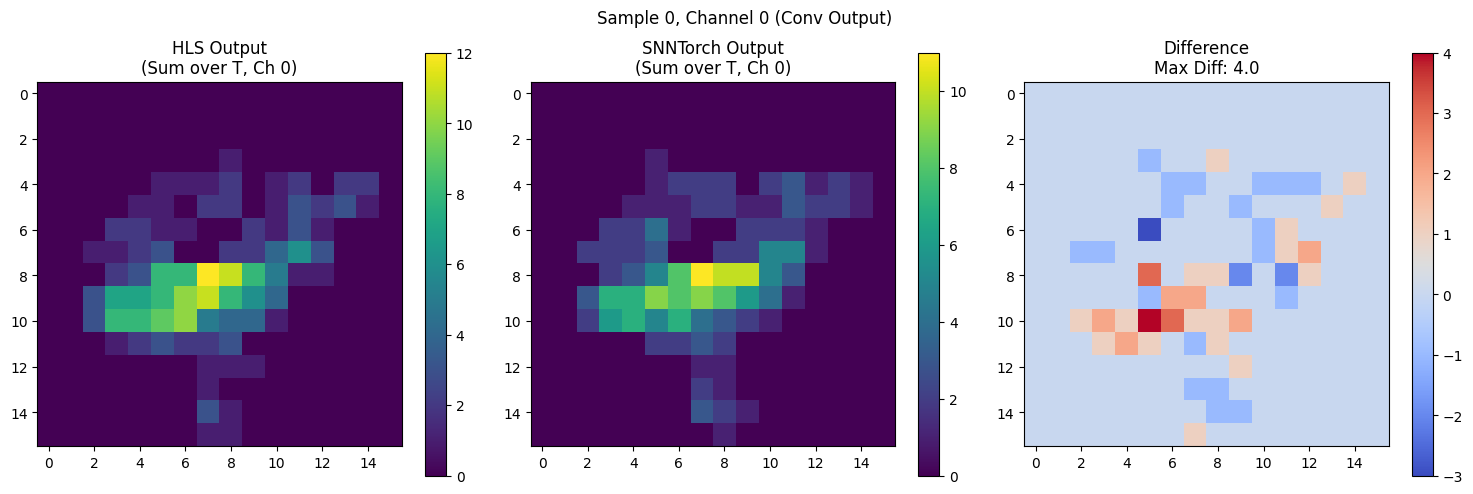

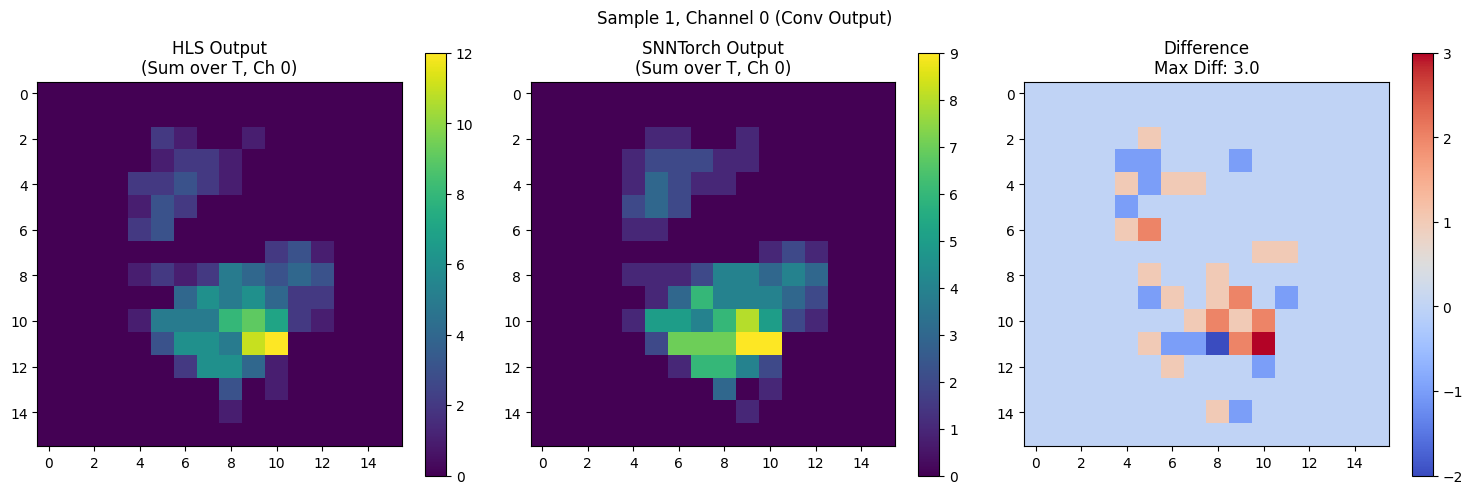

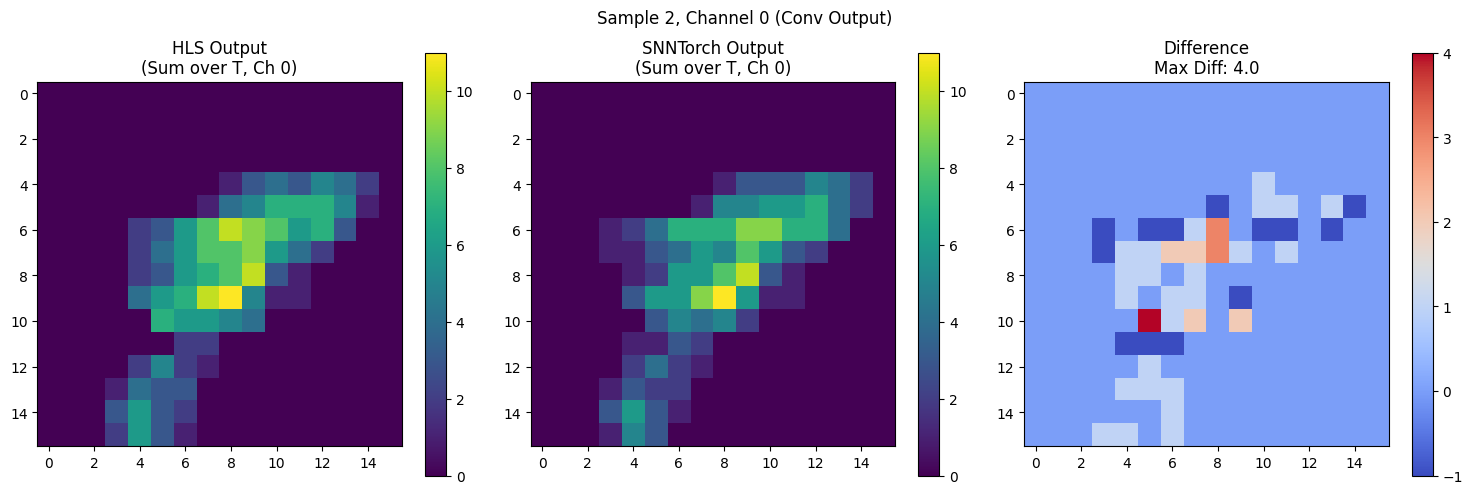

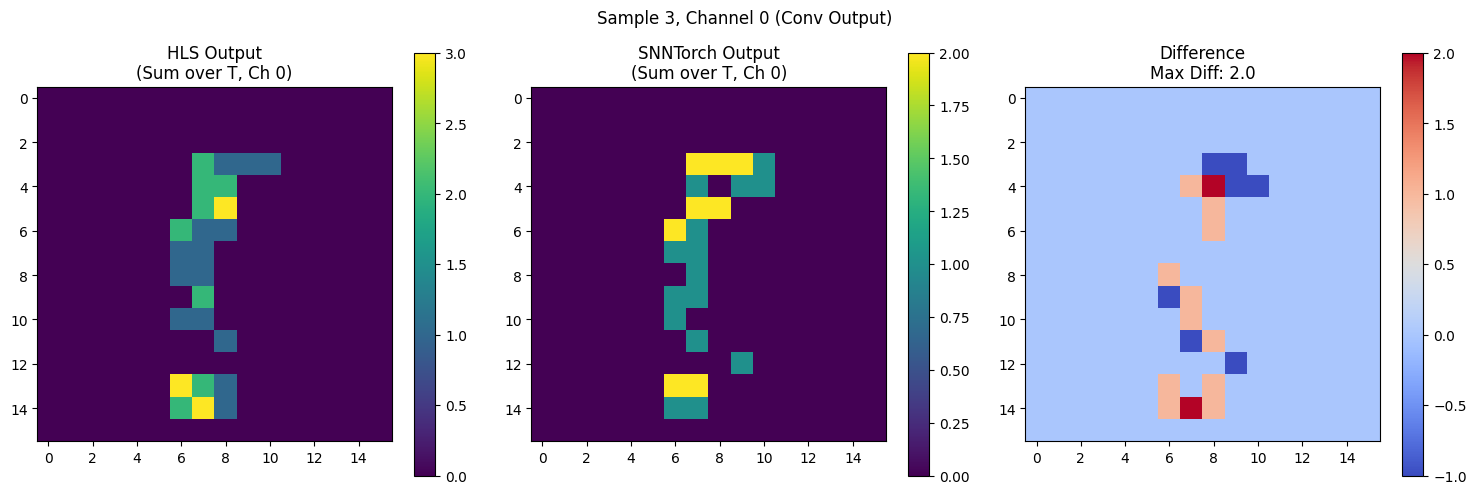

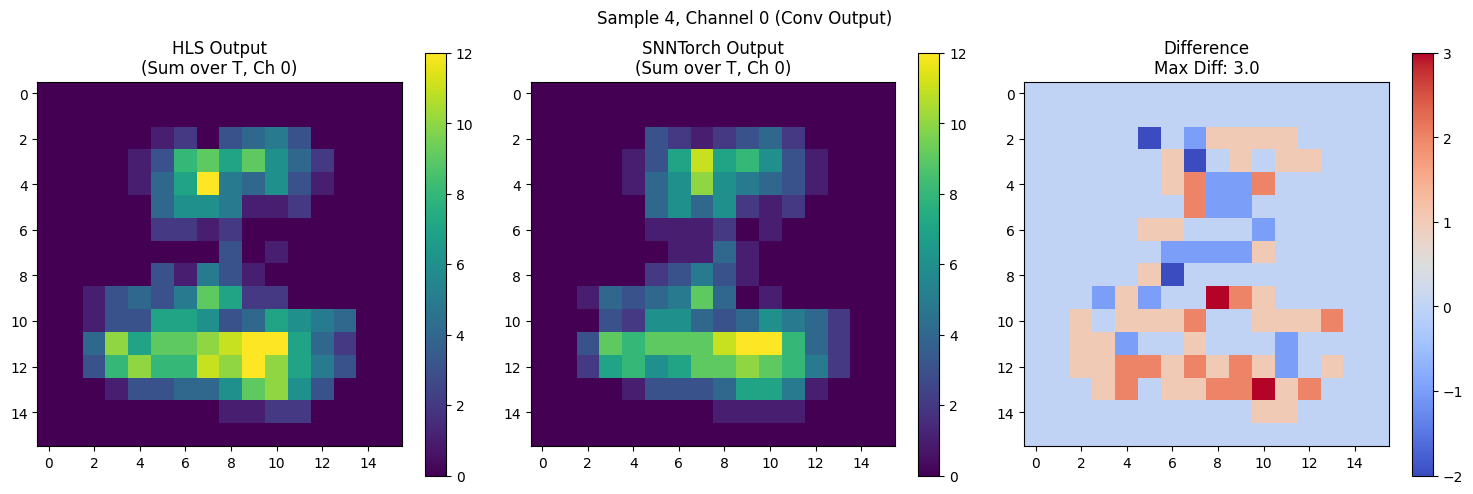

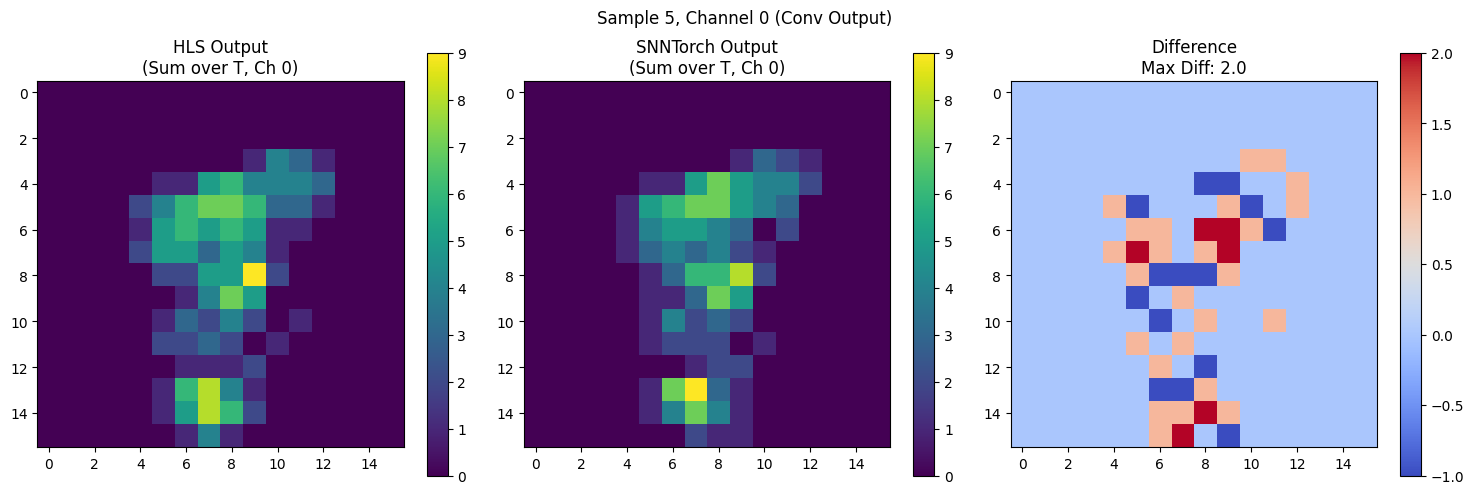

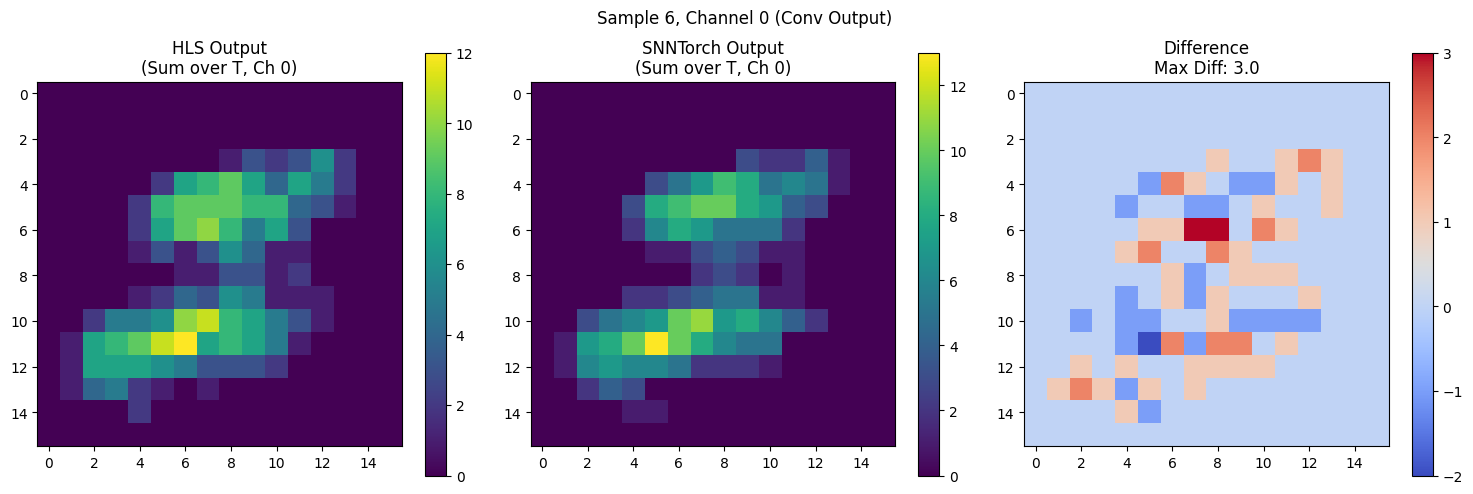

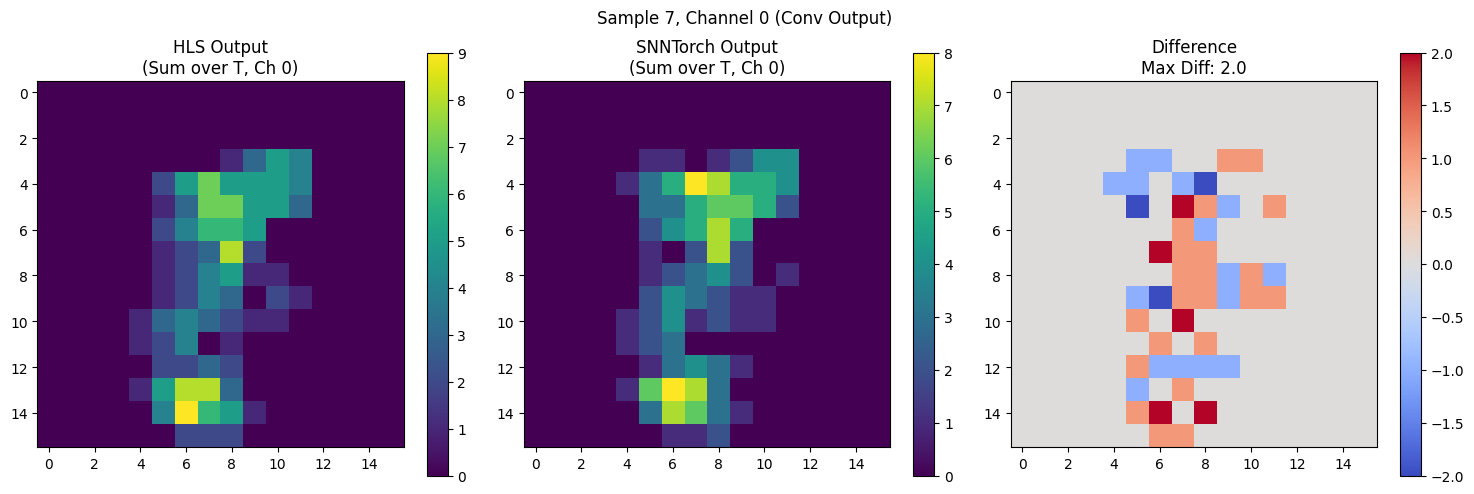

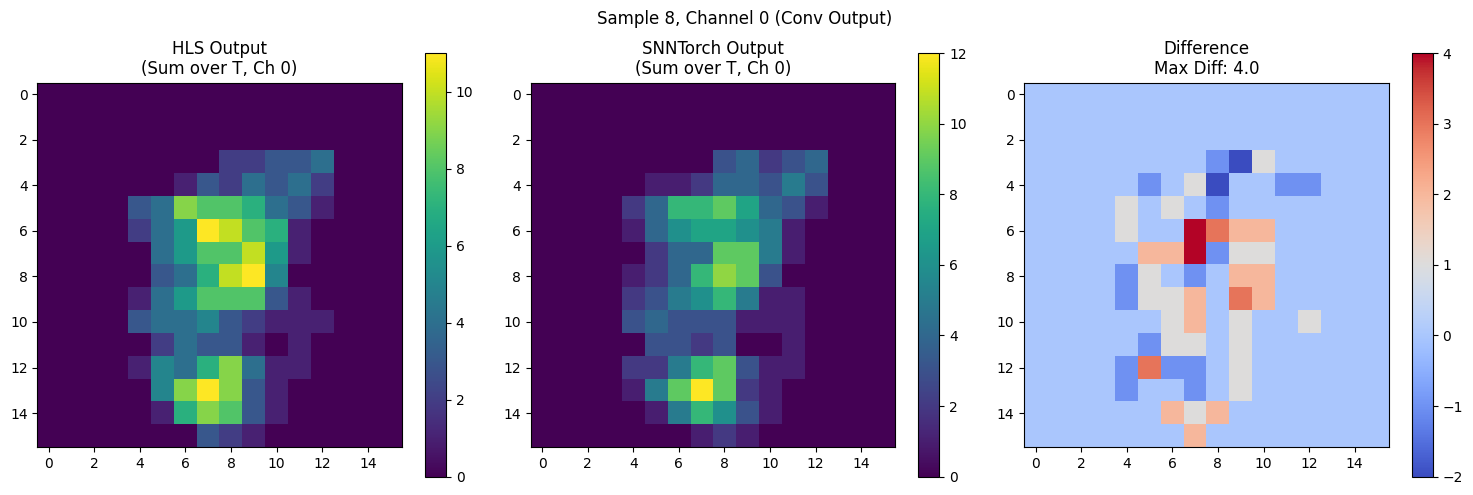

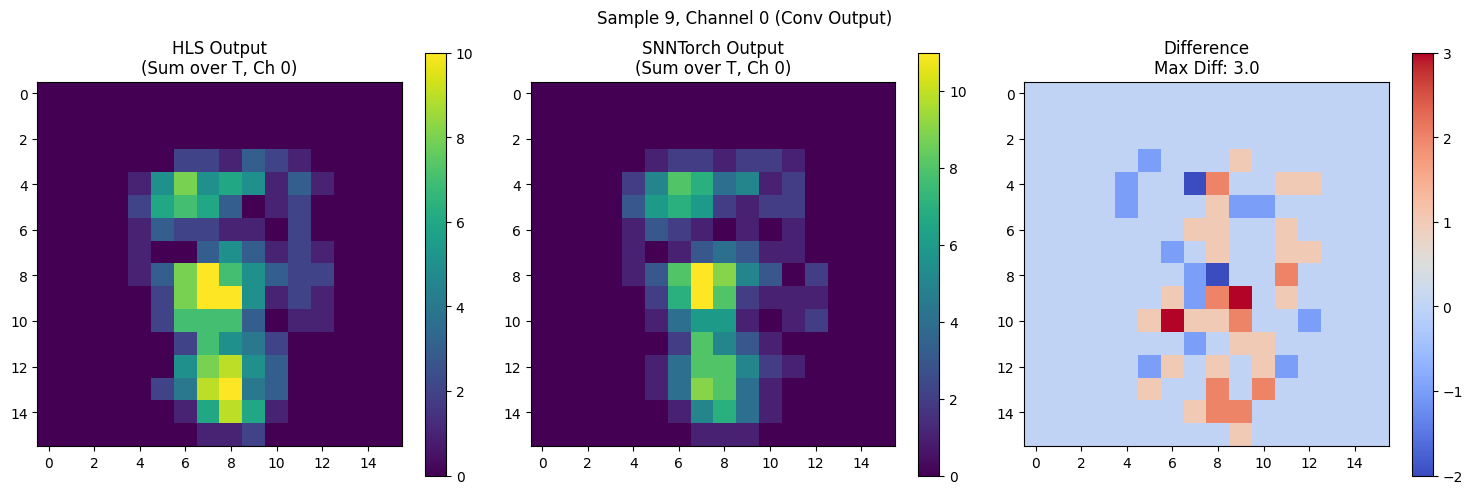

In [73]:
# Defina o número de amostras que deseja visualizar
N = 10 
channel_to_view = 0

# Garante que N não seja maior que o tamanho real do batch
max_available_samples = hls_output.shape[1]
N = min(N, max_available_samples)

print(f"Visualizando as primeiras {N} amostras...")

for i in range(N):
    visualize_comparison(hls_output, snntorch_output, sample_idx=i, channel_idx=channel_to_view)

# Mostra matriz de confusão

Overall Accuracy: 10.00%


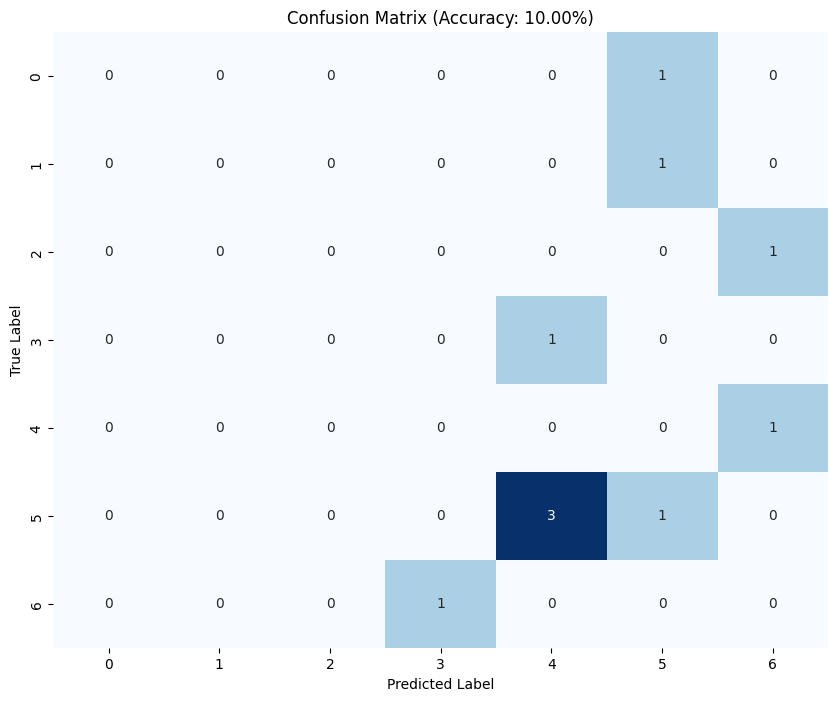

In [74]:
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score

import matplotlib.pyplot as plt

def plot_confusion_matrix_from_file(filename):
    """
    Reads a results file and plots the confusion matrix.
    Expected file format (CSV): Sample_ID, True_Label, Predicted_Class, Spike_Count, Correct
    """
    try:
        # Load data
        # Assuming the file doesn't have a header based on common HLS logs, 
        # but if it does, remove 'header=None' and 'names'.
        # Here we explicitly define names based on your description.
        df = pd.read_csv(filename, header='infer')
        
        y_true = df['True_Label']
        y_pred = df['Predicted_Class']
        
        # Calculate Accuracy
        acc = accuracy_score(y_true, y_pred)
        print(f"Overall Accuracy: {acc:.2%}")

        # Compute Confusion Matrix
        cm = confusion_matrix(y_true, y_pred)
        
        # Plot
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
        plt.xlabel('Predicted Label')
        plt.ylabel('True Label')
        plt.title(f'Confusion Matrix (Accuracy: {acc:.2%})')
        plt.show()
        
    except FileNotFoundError:
        print(f"Error: File '{filename}' not found.")
    except Exception as e:
        print(f"An error occurred: {e}")

# Example usage (replace with your actual results filename)
# Assuming the HLS or Python script generated a file named 'results_log.txt'
plot_confusion_matrix_from_file("event_driven_scnn/hls/csim/build/output_predictions.txt")